In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# <실습계획>
- 데이터 셋을 라이브러리에서 가져올 예정. 파일에서도 가져옴

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 데이터셋(훈련셋, 테스트셋)
from tensorflow.keras.utils import to_categorical  # onehot encoding
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
# 퀴즈에서는 스케일 조정, train_test_split 등을 추가

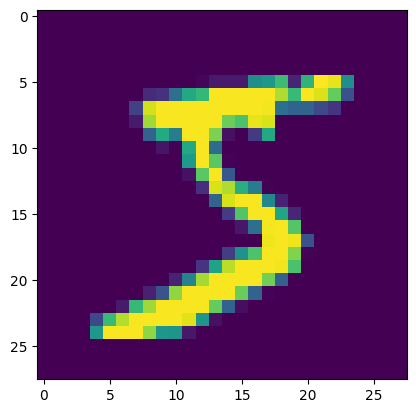

In [7]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
img = data[0, 1:].reshape(28,28)
plt.imshow(img)


In [6]:
data.shape

(100, 785)

In [8]:
print('타겟 : ', data[0,0])
# print('이미지(28*28을 1차원으로) :\n', data[0,1:].reshape(28,28))

타겟 :  5.0


In [9]:
for row in data[0,1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

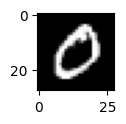

In [13]:
plt.figure(figsize=(1,1))
plt.imshow(data[1,1:].reshape(28,28), cmap='gray')

In [4]:
%pip install opencv-contrib-python

   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   -- ------------------------------------- 2.4/46.2 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.7/46.2 MB 11.4 MB/s eta 0:00:04
   ------ --------------------------------- 7.1/46.2 MB 11.5 MB/s eta 0:00:04
   ------- -------------------------------- 8.7/46.2 MB 10.3 MB/s eta 0:00:04
   -------- ------------------------------- 10.2/46.2 MB 9.7 MB/s eta 0:00:04
   --------- ------------------------------ 11.5/46.2 MB 9.1 MB/s eta 0:00:04
   ---------- ----------------------------- 12.3/46.2 MB 8.3 MB/s eta 0:00:05
   ----------- ---------------------------- 13.4/46.2 MB 7.9 MB/s eta 0:00:05
   ------------ --------------------------- 14.7/46.2 MB 7.7 MB/s eta 0:00:05
   -------------- ------------------------- 16.3/46.2 MB 7.6 MB/s eta 0:00:04
   --------------- ------------------------ 17.8/46.2 MB 7.5 MB/s eta 0:00:04
   ---------------- ----------------------- 19.1/46.2 MB 7.5 MB/s eta 0:

In [5]:
%pip install opencv-python

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/39.5 MB 10.1 MB/s eta 0:00:04
   --- ------------------------------------ 3.1/39.5 MB 7.7 MB/s eta 0:00:05
   ----- ---------------------------------- 5.0/39.5 MB 8.0 MB/s eta 0:00:05
   ------ --------------------------------- 6.3/39.5 MB 7.3 MB/s eta 0:00:05
   ------- -------------------------------- 7.9/39.5 MB 7.4 MB/s eta 0:00:05
   --------- ------------------------------ 9.2/39.5 MB 7.1 MB/s eta 0:00:05
   ---------- ----------------------------- 10.5/39.5 MB 7.0 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/39.5 MB 6.8 MB/s eta 0:00:05
   ------------- -------------------------- 13.1/39.5 MB 6.8 MB/s eta 0:00:04
   -------------- ------------------------- 14.7/39.5 MB 6.8 MB/s eta 0:00:04
   ---------------- ----------------------- 16.0/39.5 MB 6.8 MB/s eta 0:00:04
   ------------------ --------------------- 17.8/39.5 MB 6.9 MB/s eta 0:00:04

In [6]:
# 칼라사진 - >흑백모드의 넘파이배열로
import cv2

In [12]:
image_gray = cv2.imread('data/dog.jpg', cv2.IMREAD_GRAYSCALE)  #cv2.IMREAD_GRAYSCALE 그레이 스케일로 읽기
print(image_gray.shape)
print(type(image_gray))

(533, 800)
<class 'numpy.ndarray'>


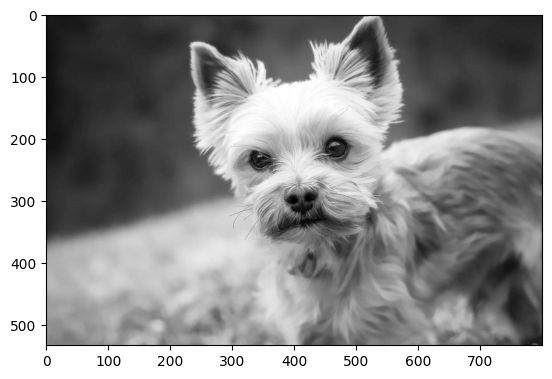

In [14]:
plt.imshow(image_gray, cmap='gray')

In [57]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [58]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [28]:
num = int(input('n번째 데이터 : '))
print('숫자 :', y_train[num])
for row in X_train[num]:
    for pix in row:
        print(f'{pix:3.0f}', end='')
    print()

n번째 데이터 : 5
숫자 : 2
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 13 25100122  7  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 33151208252252252146  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 40152244252253224211252232 40  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 15152239252252252216 31 37252252 60  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 96252252252252217 29  0 37252252 60  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0181252252220167 30  0  0 77252252 60  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 26128 58 22  0  0 

# 1. 데이터 생성 및 전처리

In [71]:
# 데이터 전처리 작업
# 데이터 생성
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋 (6만개) -> 훈련셋(5만개) + 검증셋(1만개)로 분리
X_val = X_train[-10000:]
y_val = y_train[-10000:]
X_train = X_train[:-10000]
y_train = y_train[:-10000]

# 입력(독립)변수(n, 28,28) -> (n, 784)  # 1차원, 실수형변환, 스케일조정(255.0으로 나누기)
train_X = X_train.reshape(50000,784).astype('float32')/255.0
val_X = X_val.reshape(10000,-1).astype('float32')/255
test_X = X_test.reshape(10000,-1).astype('float32')/255

# 랜덤 샘플 추출 
train_idx = np.random.choice(50000, 1000)
val_idx = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_y = y_train[train_idx]
val_X = val_X[val_idx]
val_y = y_val[val_idx]

# 타겟(종속) 변수의 원핫인코딩
train_Y = to_categorical(train_y, 10)
test_Y = to_categorical(y_test, 10)
val_Y = to_categorical(val_y, 10)
print(y_train[:2])
print(train_Y[:2])

[5 0]
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


In [72]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

((1000, 784), (1000, 10), (300, 784), (300, 10), (10000, 784), (10000, 10))

# 2. 모델 구성

In [93]:
model = Sequential()
model.add(Input(shape=(784,)))
# model.add(Dense(units=512, activation='relu'))
model.add(Dense(units=256, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_7 (Dense)             (None, 256)               200960    
                                                                 
 dense_8 (Dense)             (None, 10)                2570      
                                                                 
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
_________________________________________________________________


# 3. 모델 학습과정 설정

In [94]:
from tensorflow.keras import metrics
from tensorflow.keras.optimizers import Adam
model.compile(loss='categorical_crossentropy',  # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy',
#                      metrics.Recall(),
#                      metrics.Precision()
                     ])

# 4. 학습하기

In [95]:
%%time
hist = model.fit(train_X, train_Y,
                epochs=100,
                batch_size=700,
                validation_data=(val_X,val_Y),
                verbose=0)
# CPU times: total: 52.8 s
# Wall time: 27.3 s

CPU times: total: 8.98 s
Wall time: 4.17 s


# 5. 모델 평가하기

In [83]:
# 학습과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall_1', 'precision_1', 'val_loss', 'val_accuracy', 'val_recall_1', 'val_precision_1'])

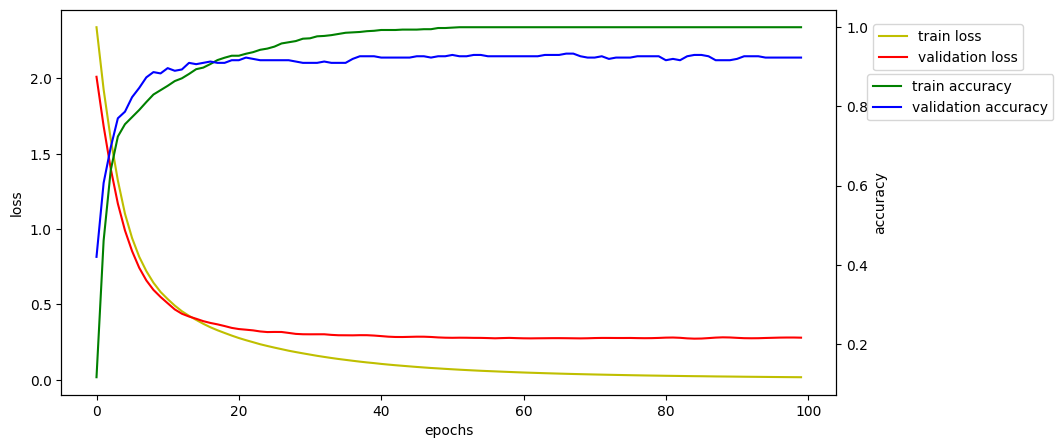

In [96]:
# 학습과정 그리기
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='validation loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), 'g', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), 'b', label='validation accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc = 'upper right', bbox_to_anchor=(1.25,0.98))
acc_ax.legend(loc = 'upper right', bbox_to_anchor=(1.289,0.85))

In [97]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, 
                                  batch_size=100,
                                  verbose=0
                                 )
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.39200061559677124
accuracy : 0.8892999887466431


# 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, 유닛수 증가)
- 과적합 방지(validation data 추가, dropout, 활성화함수)
- epoch 조정
- optimizer 변경

Epoch 1/30
500/500 [==============================] - 7s 13ms/step - loss: 0.2170 - accuracy: 0.9326 - val_loss: 0.1204 - val_accuracy: 0.9628
Epoch 2/30
500/500 [==============================] - 6s 13ms/step - loss: 0.0831 - accuracy: 0.9746 - val_loss: 0.0888 - val_accuracy: 0.9728
Epoch 3/30
500/500 [==============================] - 7s 14ms/step - loss: 0.0557 - accuracy: 0.9823 - val_loss: 0.1000 - val_accuracy: 0.9725
Epoch 4/30
500/500 [==============================] - 7s 13ms/step - loss: 0.0427 - accuracy: 0.9857 - val_loss: 0.0780 - val_accuracy: 0.9777
Epoch 5/30
500/500 [==============================] - 7s 13ms/step - loss: 0.0292 - accuracy: 0.9912 - val_loss: 0.0936 - val_accuracy: 0.9757
Epoch 6/30
500/500 [==============================] - 7s 14ms/step - loss: 0.0308 - accuracy: 0.9903 - val_loss: 0.0820 - val_accuracy: 0.9792
Epoch 7/30
500/500 [==============================] - 7s 14ms/step - loss: 0.0238 - accuracy: 0.9927 - val_loss: 0.0792 - val_accuracy: 0.9789

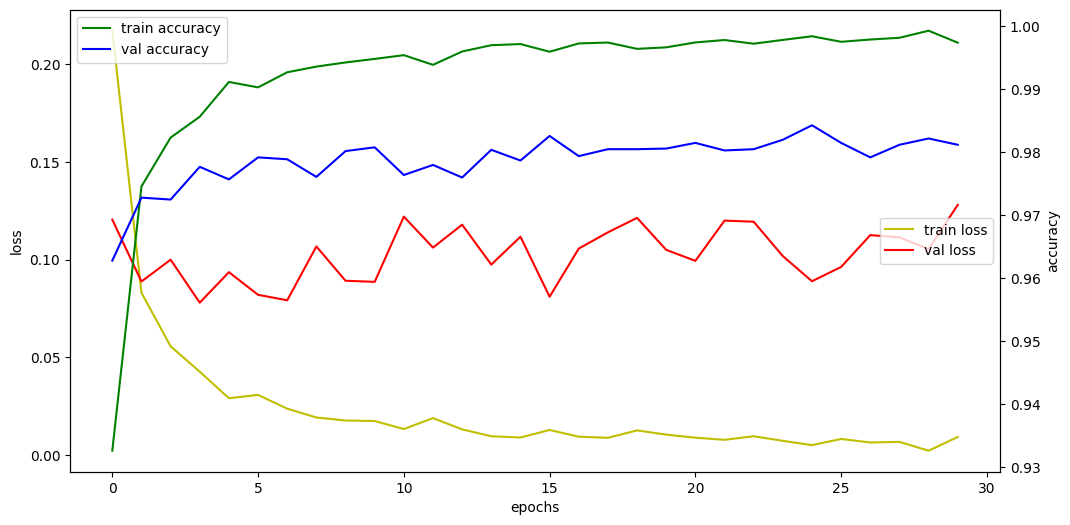

loss : 0.11125922948122025
accuracy : 0.9811999797821045
CPU times: total: 16min 59s
Wall time: 3min 40s


In [99]:
%%time

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

# 랜덤 샘플 추출 
# 데이터 5만 -> 700개 / 10000개 -> 300개
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]

# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dense(units=500, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

hist = model.fit(train_X, train_Y,
                epochs=30,
                batch_size=100,
                validation_data=(val_X, val_Y))

fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

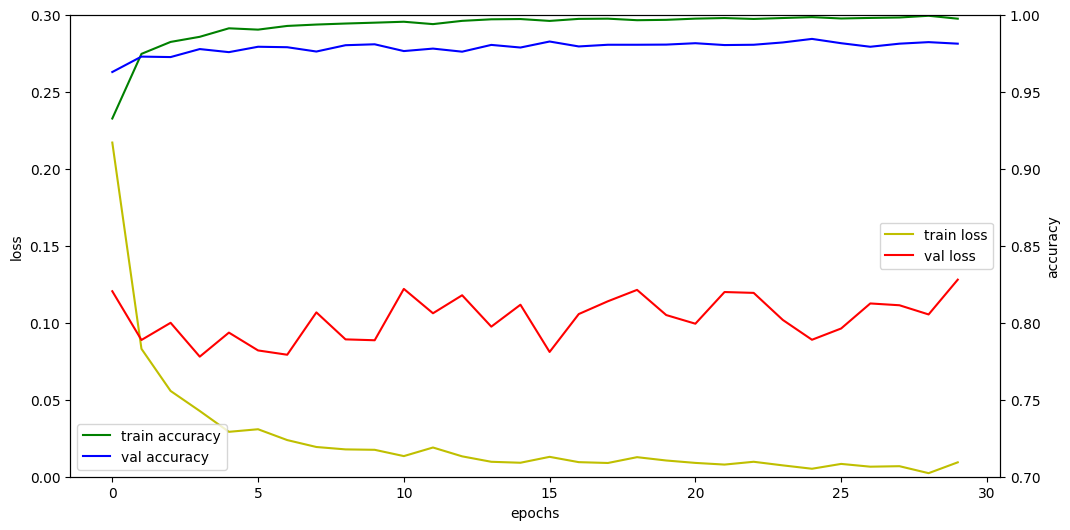

In [105]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
loss_ax.set_ylim(ymin=0, ymax=0.3)
acc_ax.set_ylim(ymin=0.7, ymax=1)
plt.show()

In [106]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.11125922948122025
accuracy : 0.9811999797821045


In [125]:
save_model(model, 'model/08_mnsit.h5')

In [112]:
# 실제값
np.all(y_test == test_Y.argmax(axis=1))
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [116]:
# 예측값
y_hat = model.predict(test_X).argmax(axis=1)
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 1s 4ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [117]:
pd.crosstab(y_test,y_hat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,972,1,1,0,0,0,3,1,2,0
1,1,1121,2,3,0,0,3,0,5,0
2,4,0,1015,4,1,0,1,2,5,0
3,0,0,4,994,0,5,0,3,4,0
4,4,1,2,1,953,0,7,2,2,10
5,2,0,0,9,0,874,3,0,3,1
6,5,2,0,0,3,2,943,0,3,0
7,3,1,9,3,1,0,0,1006,2,3
8,5,0,2,8,2,3,0,3,950,1


In [118]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 972,    1,    1,    0,    0,    0,    3,    1,    2,    0],
       [   1, 1121,    2,    3,    0,    0,    3,    0,    5,    0],
       [   4,    0, 1015,    4,    1,    0,    1,    2,    5,    0],
       [   0,    0,    4,  994,    0,    5,    0,    3,    4,    0],
       [   4,    1,    2,    1,  953,    0,    7,    2,    2,   10],
       [   2,    0,    0,    9,    0,  874,    3,    0,    3,    1],
       [   5,    2,    0,    0,    3,    2,  943,    0,    3,    0],
       [   3,    1,    9,    3,    1,    0,    0, 1006,    2,    3],
       [   5,    0,    2,    8,    2,    3,    0,    3,  950,    1],
       [   1,    2,    0,    3,    5,    5,    1,    5,    3,  984]],
      dtype=int64)

In [121]:
# 틀린갯수 
10000- 10000*loss_and_metrics[1]

188.00020217895508

In [124]:
cnt = 0
for y, h in zip(y_test, y_hat):
    if y != h:
        cnt += 1
print('틀린갯수 :', cnt)

틀린갯수 : 188


# ※ 콜백함수1 : 로그 출력

In [126]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [131]:
%%time
# 매번 로그출력하면 메세지가 과다. 특정 epochs마다 로그 출력하도록 제한
class CustomHistory(Callback):  # 콜백에게 상속 받는 클래스 생성
    def __init__(self): # 생성자 함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}): # 1 epoch 마다 자동실행되는 함수
        self.epoch += 1
        if self.epoch%10==0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                  format(self.epoch,
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')))
    
    
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

# 랜덤 샘플 추출 
# 데이터 5만 -> 700개 / 10000개 -> 300개
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]

# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=500, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

customHistory = CustomHistory()

hist = model.fit(train_X, train_Y,
                epochs=300,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory], # 콜백함수
                ) 



epoch:10, loss:0.03318268433213234, acc:0.9900000095367432, val_loss:0.27753111720085144, val_acc:0.9166666865348816
epoch:20, loss:0.008532953448593616, acc:0.9971428513526917, val_loss:0.39023494720458984, val_acc:0.9066666960716248
epoch:30, loss:0.0010763892205432057, acc:1.0, val_loss:0.4249955117702484, val_acc:0.8766666650772095
epoch:40, loss:0.004748316947370768, acc:0.9985714554786682, val_loss:0.466581255197525, val_acc:0.8866666555404663
epoch:50, loss:0.0005682322080247104, acc:1.0, val_loss:0.38005173206329346, val_acc:0.9233333468437195
epoch:60, loss:0.00015518268628511578, acc:1.0, val_loss:0.3771999776363373, val_acc:0.9233333468437195
epoch:70, loss:0.00016469156253151596, acc:1.0, val_loss:0.4008459448814392, val_acc:0.9200000166893005
epoch:80, loss:7.554724288638681e-05, acc:1.0, val_loss:0.3838455080986023, val_acc:0.9200000166893005
epoch:90, loss:8.399737271247432e-05, acc:1.0, val_loss:0.4025236666202545, val_acc:0.9166666865348816
epoch:100, loss:5.5526983487

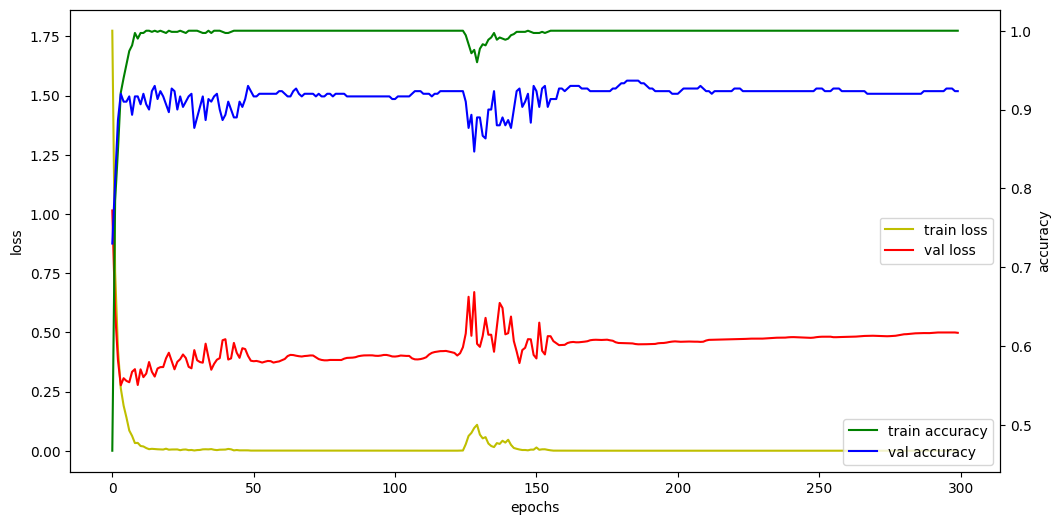

loss : 0.6194586157798767
accuracy : 0.9081000089645386


In [132]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy 값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [139]:
%%time

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

# 랜덤 샘플 추출 
# 데이터 5만 -> 2000개 / 10000개 -> 600개
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 600)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]

# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=500, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])


# 학습
earlystopping = EarlyStopping(monitor='val_loss',  # val_loss 가 기본값, val_loss를 기준으로 보겠다
                             patience=20)   # patience 수 많큼 참아주겠다, 보통은 40~50은 넣는다
                             
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping], # 콜백함수
                ) 



Epoch 1/500
20/20 [==============================] - 1s 25ms/step - loss: 1.1319 - accuracy: 0.6500 - val_loss: 0.4288 - val_accuracy: 0.8700
Epoch 2/500
20/20 [==============================] - 0s 15ms/step - loss: 0.4511 - accuracy: 0.8585 - val_loss: 0.3282 - val_accuracy: 0.8867
Epoch 3/500
20/20 [==============================] - 0s 16ms/step - loss: 0.3090 - accuracy: 0.9030 - val_loss: 0.2422 - val_accuracy: 0.9233
Epoch 4/500
20/20 [==============================] - 0s 16ms/step - loss: 0.1672 - accuracy: 0.9460 - val_loss: 0.2079 - val_accuracy: 0.9383
Epoch 5/500
20/20 [==============================] - 0s 17ms/step - loss: 0.1027 - accuracy: 0.9775 - val_loss: 0.2193 - val_accuracy: 0.9367
Epoch 6/500
20/20 [==============================] - 0s 15ms/step - loss: 0.0875 - accuracy: 0.9755 - val_loss: 0.1905 - val_accuracy: 0.9467
Epoch 7/500
20/20 [==============================] - 0s 15ms/step - loss: 0.0470 - accuracy: 0.9895 - val_loss: 0.1922 - val_accuracy: 0.9500
Epoch 

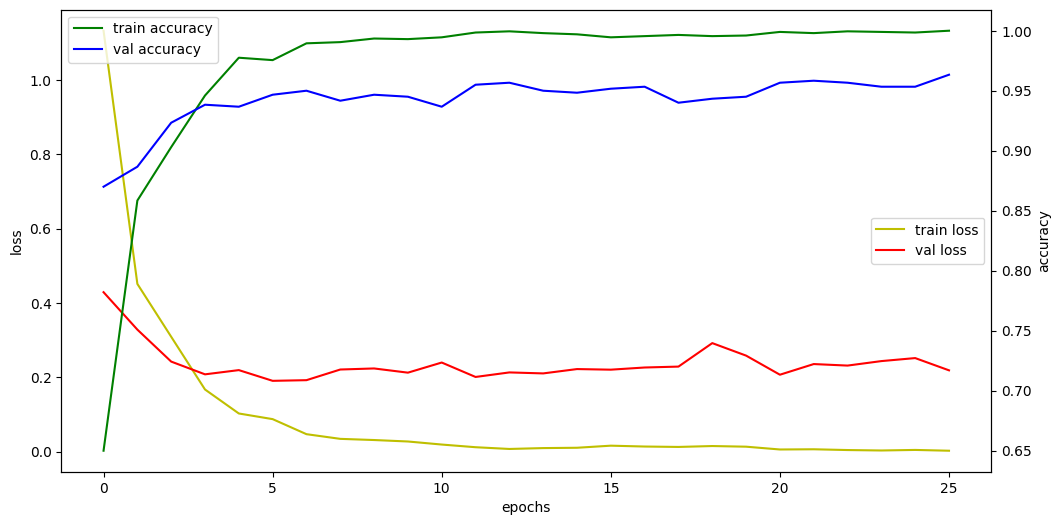

loss : 0.3097250759601593
accuracy : 0.9383000135421753


In [140]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

# ※ 콜백함수3 : 자동저장

In [141]:
%%time

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0

# 랜덤 샘플 추출 
# 데이터 5만 -> 2000개 / 10000개 -> 600개
train_idx = np.random.choice(50000, 2000)
val_idx  = np.random.choice(10000, 600)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]

# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=500, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])


# 학습
# 특정조건을 만족하면 조기 종료
earlystopping = EarlyStopping(monitor='val_accuracy',  # val_loss 가 기본값, val_accuracy 기준으로 보겠다
                             patience=10)   # patience 수 많큼 참아주겠다, 보통은 40~50은 넣는다

# 모델 자동 저장 콜백(경로 및 파일명 규칙 지정)
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder):  # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder+ 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'  # f 스트링 안해도 됨. 왜?
    
    
checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy',  # 모니터 지표
                            save_best_only=True,  # 모니터 지표가 개선된 경우만 저장
                            mode = 'max',  # max : 값이 커질수록 저장 / min : 값이 작아질수록 / auto : 알아서 하겠다
                            verbose=1)  # 저장시 로그 출력

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint] # 콜백함수
                ) 



Epoch 1/500
17/20 [========================>.....] - ETA: 0s - loss: 1.2713 - accuracy: 0.6206
Epoch 1: val_accuracy improved from -inf to 0.86500, saving model to ./model08\mnist-001-val0.8650.h5
20/20 [==============================] - 1s 27ms/step - loss: 1.1628 - accuracy: 0.6510 - val_loss: 0.4398 - val_accuracy: 0.8650
Epoch 2/500
17/20 [========================>.....] - ETA: 0s - loss: 0.4082 - accuracy: 0.8788
Epoch 2: val_accuracy improved from 0.86500 to 0.90500, saving model to ./model08\mnist-002-val0.9050.h5
20/20 [==============================] - 0s 19ms/step - loss: 0.3968 - accuracy: 0.8840 - val_loss: 0.3607 - val_accuracy: 0.9050
Epoch 3/500
18/20 [==========================>...] - ETA: 0s - loss: 0.2154 - accuracy: 0.9383
Epoch 3: val_accuracy did not improve from 0.90500
20/20 [==============================] - 0s 15ms/step - loss: 0.2185 - accuracy: 0.9380 - val_loss: 0.3332 - val_accuracy: 0.9000
Epoch 4/500
17/20 [========================>.....] - ETA: 0s - loss

Epoch 29/500
18/20 [==========================>...] - ETA: 0s - loss: 0.0011 - accuracy: 1.0000
Epoch 29: val_accuracy did not improve from 0.93167
20/20 [==============================] - 0s 15ms/step - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.4353 - val_accuracy: 0.9233
Epoch 30/500
19/20 [===========================>..] - ETA: 0s - loss: 0.0015 - accuracy: 0.9995
Epoch 30: val_accuracy did not improve from 0.93167
20/20 [==============================] - 0s 15ms/step - loss: 0.0015 - accuracy: 0.9995 - val_loss: 0.4348 - val_accuracy: 0.9217
Epoch 31/500
17/20 [========================>.....] - ETA: 0s - loss: 0.0072 - accuracy: 0.9976
Epoch 31: val_accuracy did not improve from 0.93167
20/20 [==============================] - 0s 17ms/step - loss: 0.0073 - accuracy: 0.9975 - val_loss: 0.5107 - val_accuracy: 0.9250
Epoch 32/500
17/20 [========================>.....] - ETA: 0s - loss: 0.0188 - accuracy: 0.9924
Epoch 32: val_accuracy did not improve from 0.93167
20/20 [===========